# Model Evaluation & Visualizations

In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 3")

## Section 1 : Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb

In [5]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='darkgrid')

## Section 2 : Load Predictions & Actuals

In [6]:
# Load actual values
actual_ts   = pd.read_csv('predictions/actual_ts.csv',   index_col=0, parse_dates=True).squeeze()
actual_ml   = pd.read_csv('predictions/actual_ml.csv',   index_col=0, parse_dates=True).squeeze()
actual_lstm = pd.read_csv('predictions/actual_lstm.csv', index_col=0, parse_dates=True).squeeze()

In [7]:
# Load model predictions
arima_pred   = pd.read_csv('predictions/arima_pred.csv',   index_col=0, parse_dates=True).squeeze()
sarima_pred  = pd.read_csv('predictions/sarima_pred.csv',  index_col=0, parse_dates=True).squeeze()
prophet_pred = pd.read_csv('predictions/prophet_pred.csv', index_col=0, parse_dates=True).squeeze()
xgb_pred     = pd.read_csv('predictions/xgb_pred.csv',     index_col=0, parse_dates=True).squeeze()
lgb_pred     = pd.read_csv('predictions/lgb_pred.csv',     index_col=0, parse_dates=True).squeeze()
lstm_pred    = pd.read_csv('predictions/lstm_pred.csv',    index_col=0, parse_dates=True).squeeze()

In [8]:
# Full dataset for context
df = pd.read_csv('BTC_cleaned.csv', index_col='Date', parse_dates=True)

## Section 3 : Evaluation Metrics

In [9]:
def evaluate(name, actual, predicted):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    # Align lengths
    n = min(len(actual), len(predicted))
    actual, predicted = actual[:n], predicted[:n]

    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mae   = mean_absolute_error(actual, predicted)
    mape  = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2    = 1 - np.sum((actual - predicted)**2) / np.sum((actual - actual.mean())**2)
    da    = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted))) * 100

    print(f'  RMSE  : ${rmse:>12,.2f}')
    print(f'  MAE   : ${mae:>12,.2f}')
    print(f'  MAPE  : {mape:>12.2f}%')
    print(f'  R²    : {r2:>12.4f}')
    print(f'  Dir.Acc: {da:>11.1f}%')
    return {'Model': name, 'RMSE': round(rmse,2), 'MAE': round(mae,2),
        'MAPE': round(mape,2), 'R2': round(r2,4), 'Dir_Acc': round(da,1)}

In [10]:
results = []
for name, actual, pred in [
    ('ARIMA',    actual_ts,   arima_pred),
    ('SARIMA',   actual_ts,   sarima_pred),
    ('Prophet',  actual_ts,   prophet_pred),
    ('XGBoost',  actual_ml,   xgb_pred),
    ('LightGBM', actual_ml,   lgb_pred),
    ('LSTM',     actual_lstm, lstm_pred),
    ]:
    print(f'\n── {name} ──')
    results.append(evaluate(name, actual, pred))


── ARIMA ──
  RMSE  : $   20,570.30
  MAE   : $   13,970.71
  MAPE  :        31.21%
  R²    :      -0.4951
  Dir.Acc:        50.6%

── SARIMA ──
  RMSE  : $   41,037.50
  MAE   : $   37,965.23
  MAPE  :       115.78%
  R²    :      -4.9504
  Dir.Acc:        48.2%

── Prophet ──
  RMSE  : $   21,470.72
  MAE   : $   18,166.56
  MAPE  :        58.31%
  R²    :      -0.6289
  Dir.Acc:        50.1%

── XGBoost ──
  RMSE  : $    1,413.36
  MAE   : $      760.19
  MAPE  :         1.81%
  R²    :       0.9931
  Dir.Acc:        84.7%

── LightGBM ──
  RMSE  : $    1,701.84
  MAE   : $      894.03
  MAPE  :         2.09%
  R²    :       0.9900
  Dir.Acc:        84.2%

── LSTM ──
  RMSE  : $    1,568.61
  MAE   : $      992.07
  MAPE  :         2.52%
  R²    :       0.9914
  Dir.Acc:        45.4%


In [11]:
# Leaderboard
    
results_df = pd.DataFrame(results).set_index('Model').sort_values('RMSE')
print('\n  MODEL LEADERBOARD (sorted by RMSE)\n')
print(results_df.to_string())
best = results_df.index[0]
print(f'\n  Best Model: {best}')


  MODEL LEADERBOARD (sorted by RMSE)

              RMSE       MAE    MAPE      R2  Dir_Acc
Model                                                
XGBoost    1413.36    760.19    1.81  0.9931     84.7
LSTM       1568.61    992.07    2.52  0.9914     45.4
LightGBM   1701.84    894.03    2.09  0.9900     84.2
ARIMA     20570.30  13970.71   31.21 -0.4951     50.6
Prophet   21470.72  18166.56   58.31 -0.6289     50.1
SARIMA    41037.50  37965.23  115.78 -4.9504     48.2

  Best Model: XGBoost


## Section 4 : Individual Model Prediction Plots

In [12]:
def plot_pred(actual, predicted, name, color, filename):
    n = min(len(actual), len(predicted))
    act = actual[:n]
    pred = np.array(predicted)[:n]
    idx = act.index if hasattr(act, 'index') else range(n)
    
    plt.figure(figsize=(14, 5))
    plt.plot(idx, act.values, label='Actual', color='#F7931A', linewidth=1.8)
    plt.plot(idx, pred,       label=f'{name} Prediction', color=color, linewidth=1.5, linestyle='--')
    
    # Shade error
    plt.fill_between(idx, act.values, pred, alpha=0.12, color=color)
    
    rmse = np.sqrt(mean_squared_error(act.values, pred))
    plt.title(f'{name} — Bitcoin Price Prediction  |  RMSE: ${rmse:,.0f}', fontsize=13, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Close Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

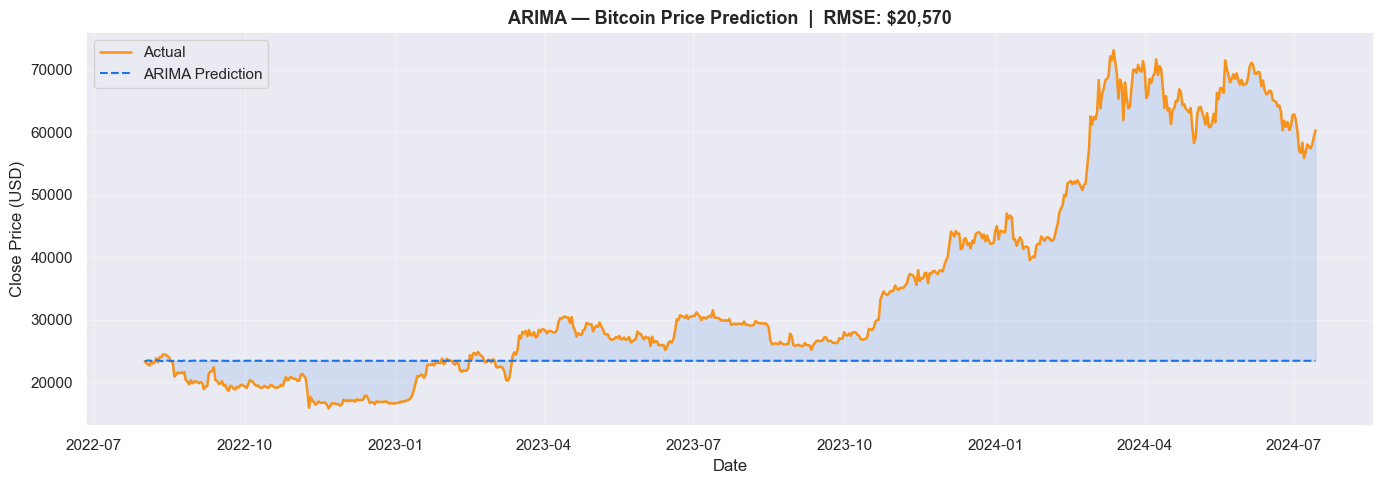

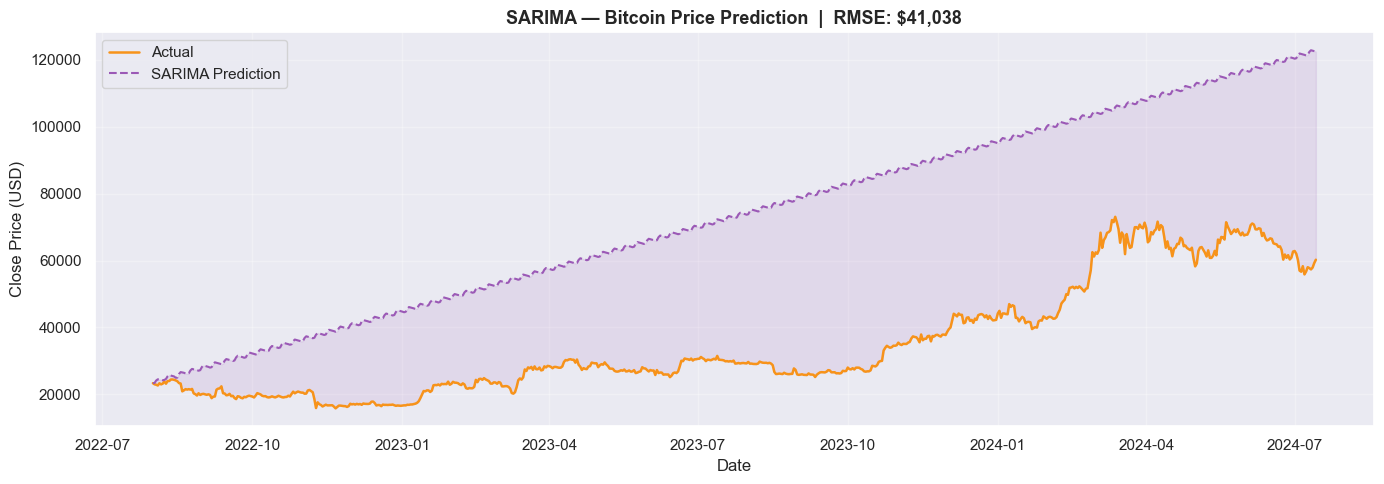

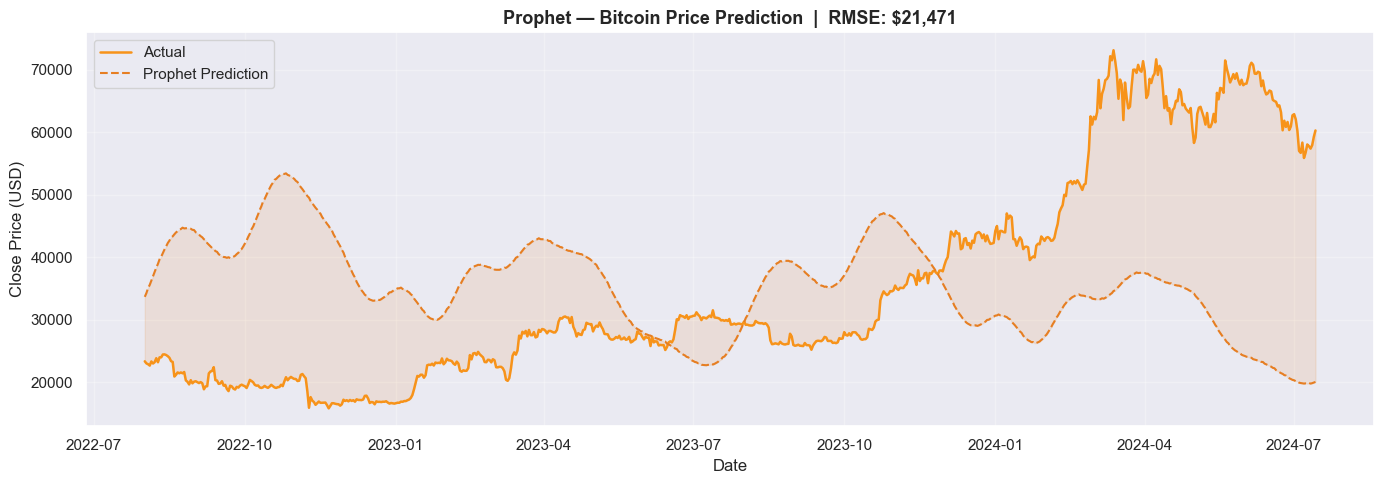

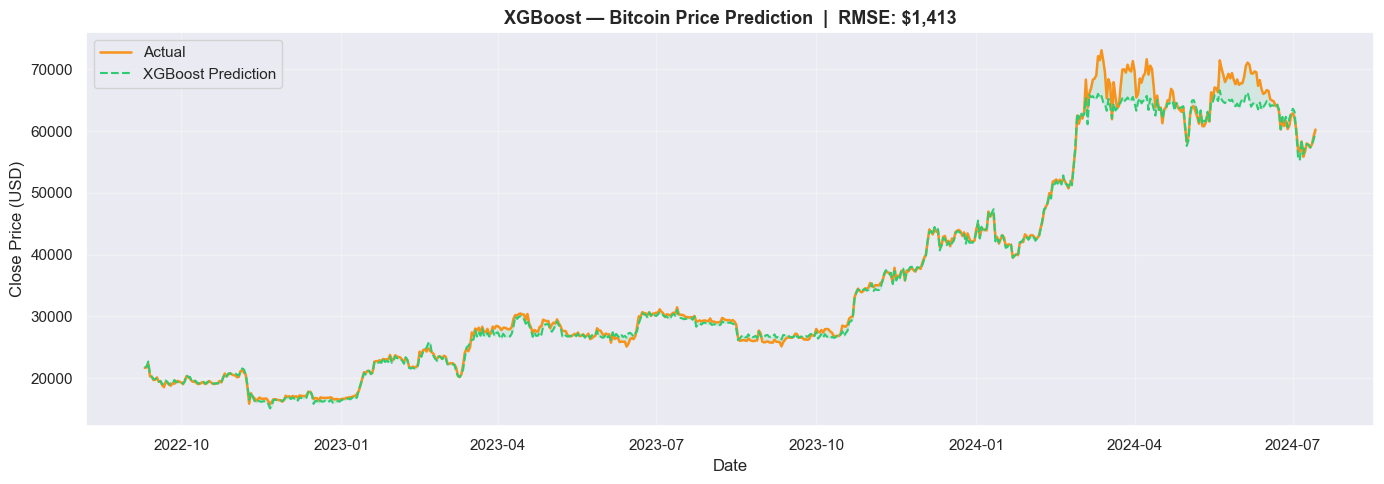

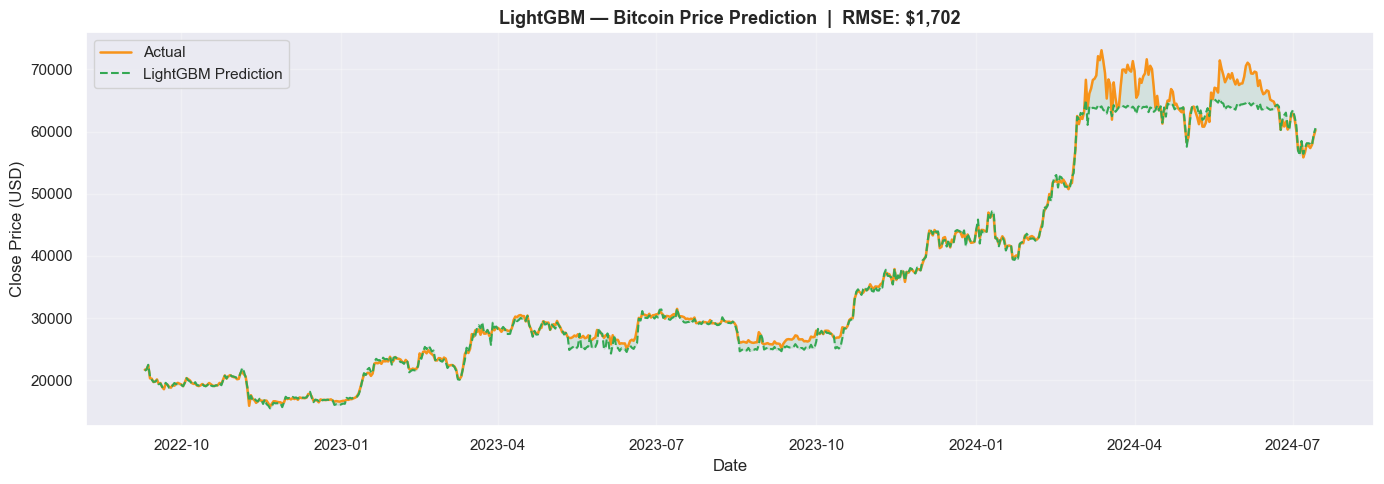

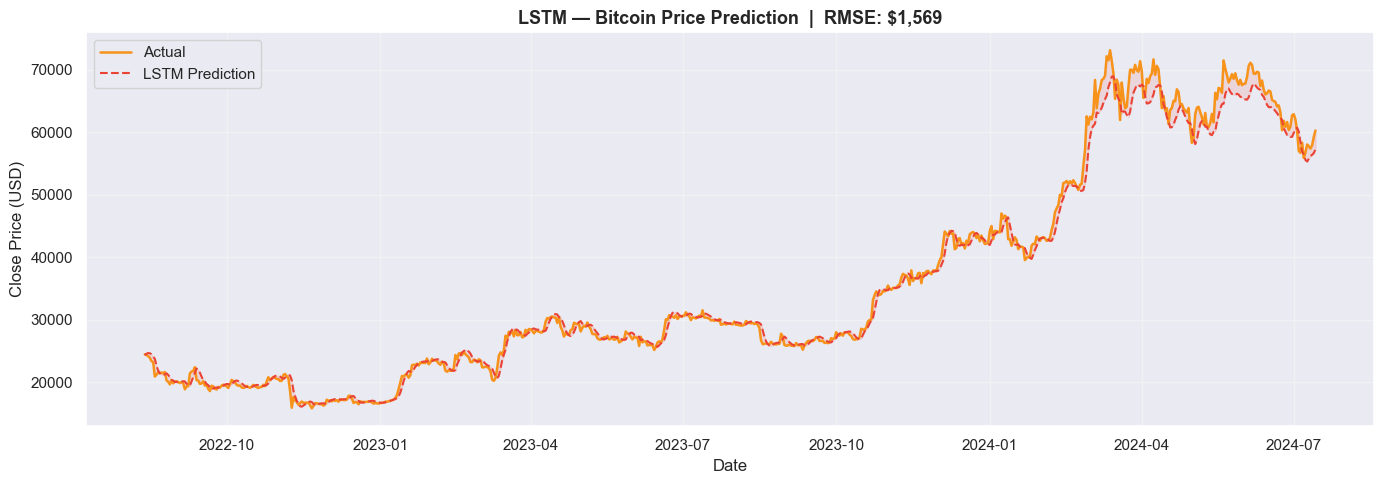

In [13]:
plot_pred(actual_ts,   arima_pred,   'ARIMA',    '#1A73E8', 'nb3_01_arima.png')
plot_pred(actual_ts,   sarima_pred,  'SARIMA',   '#9B59B6', 'nb3_02_sarima.png')
plot_pred(actual_ts,   prophet_pred, 'Prophet',  '#E67E22', 'nb3_03_prophet.png')
plot_pred(actual_ml,   xgb_pred,     'XGBoost',  '#2ECC71', 'nb3_04_xgboost.png')
plot_pred(actual_ml,   lgb_pred,     'LightGBM', '#34A853', 'nb3_05_lightgbm.png')
plot_pred(actual_lstm, lstm_pred,    'LSTM',     '#EA4335', 'nb3_06_lstm.png')

## Section 5 : All Models Overlay

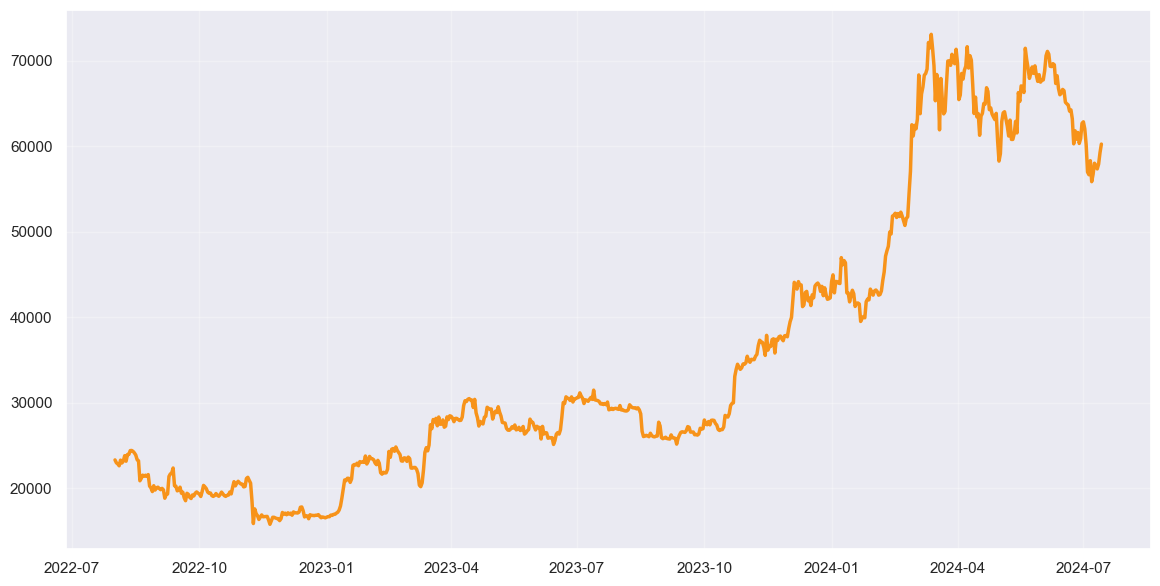

In [14]:
plt.figure(figsize=(14, 7))
plt.plot(actual_ts.index, actual_ts.values, label='Actual', color='#F7931A', linewidth=2.5, zorder=6)

In [15]:
model_preds = [
    ('ARIMA',    actual_ts.index,   arima_pred.values,        '#1A73E8', '--'),
    ('SARIMA',   actual_ts.index,   sarima_pred.values,       '#9B59B6', '--'),
    ('Prophet',  actual_ts.index,   prophet_pred.values,      '#E67E22', '-.'),
    ('XGBoost',  actual_ml.index,   xgb_pred.values,          '#2ECC71', ':'),
    ('LightGBM', actual_ml.index,   lgb_pred.values,          '#34A853', ':'),
    ('LSTM',     actual_lstm.index, lstm_pred.values[:len(actual_lstm)], '#EA4335', '-.')
    ]

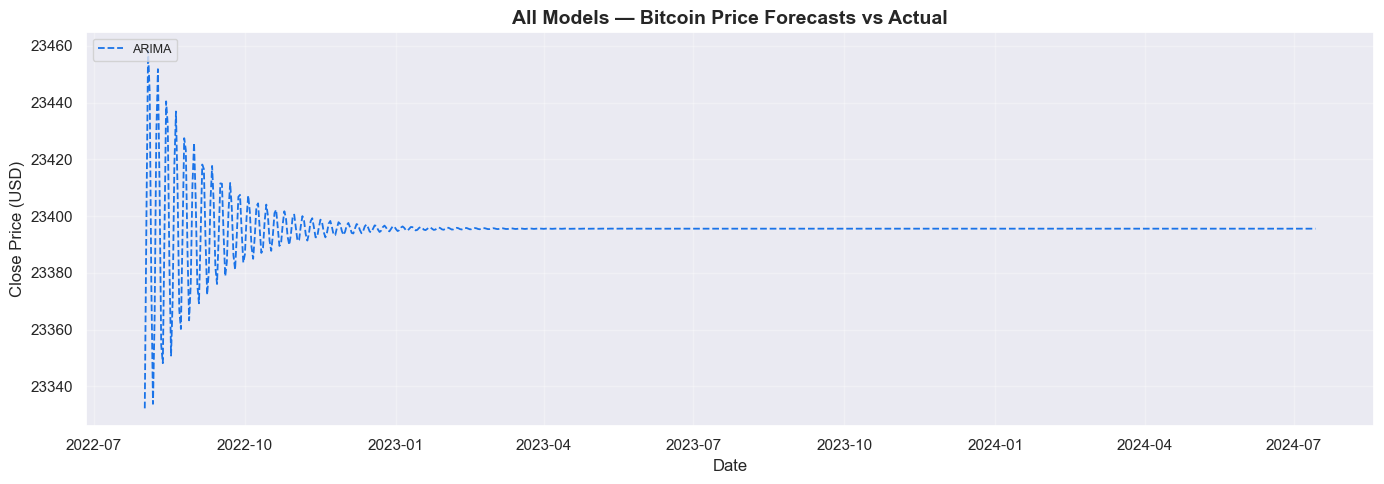

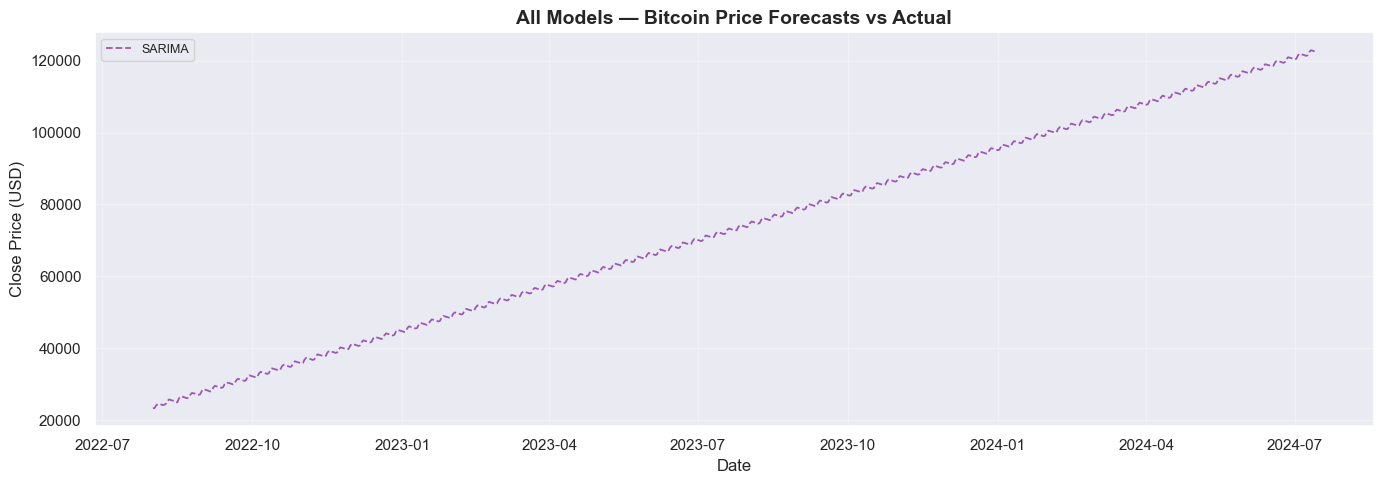

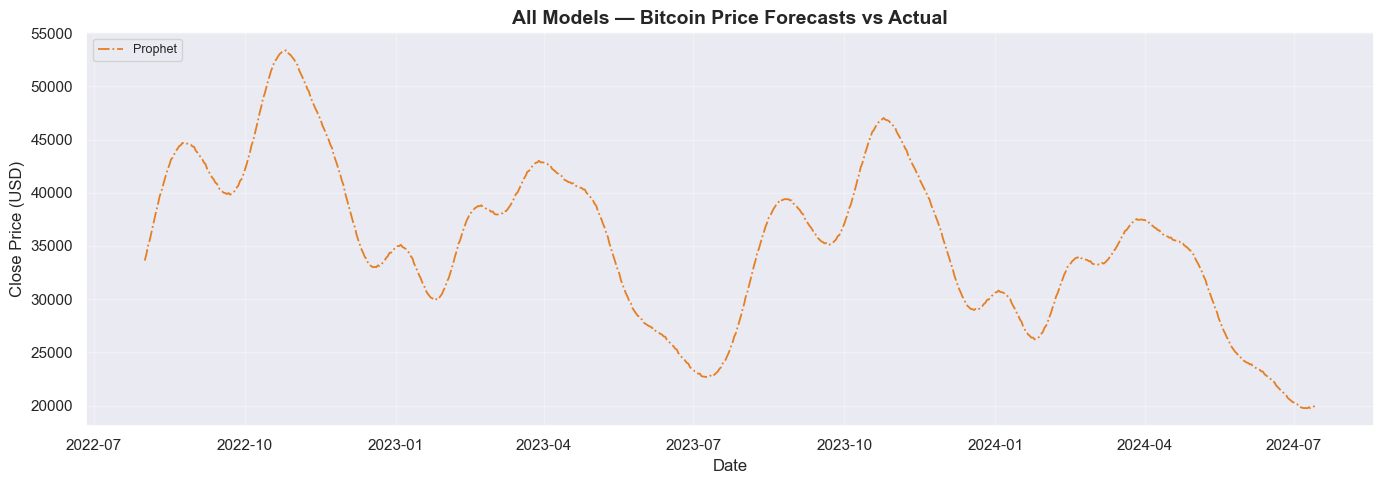

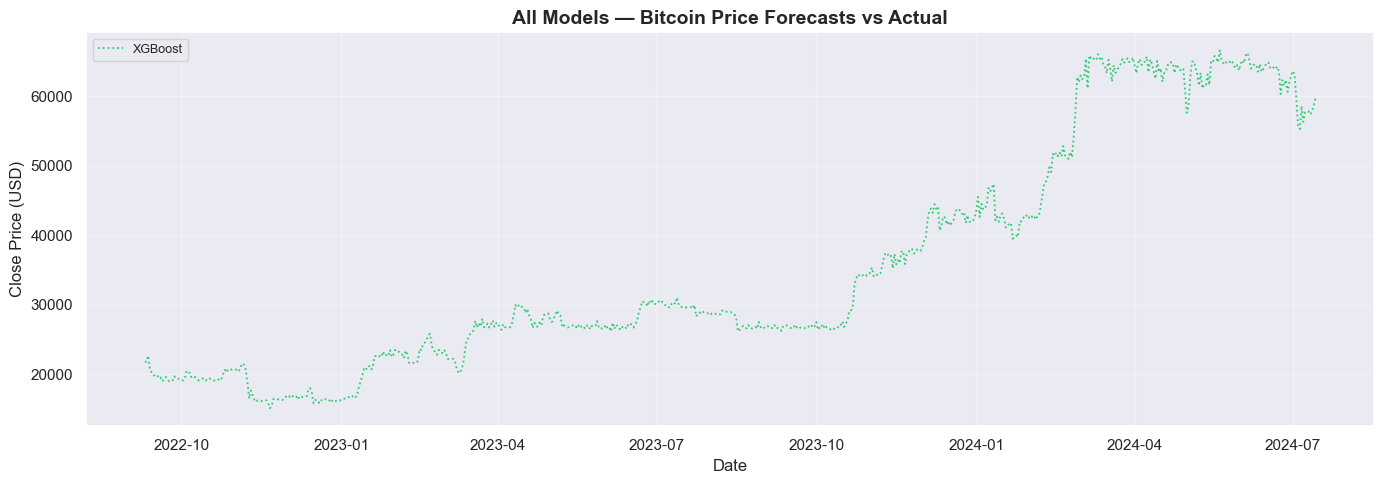

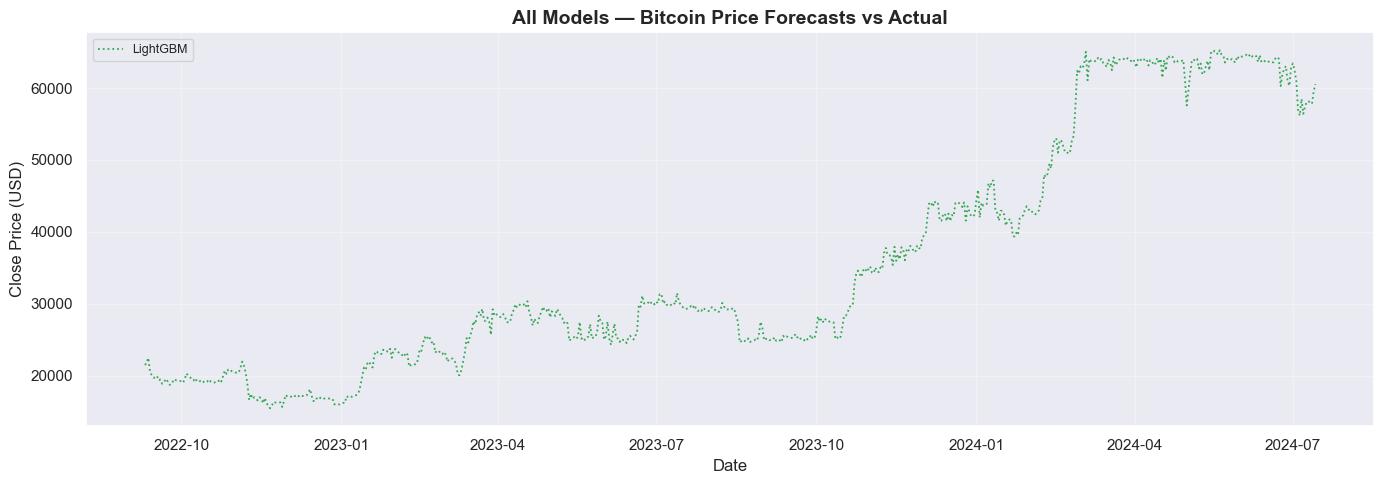

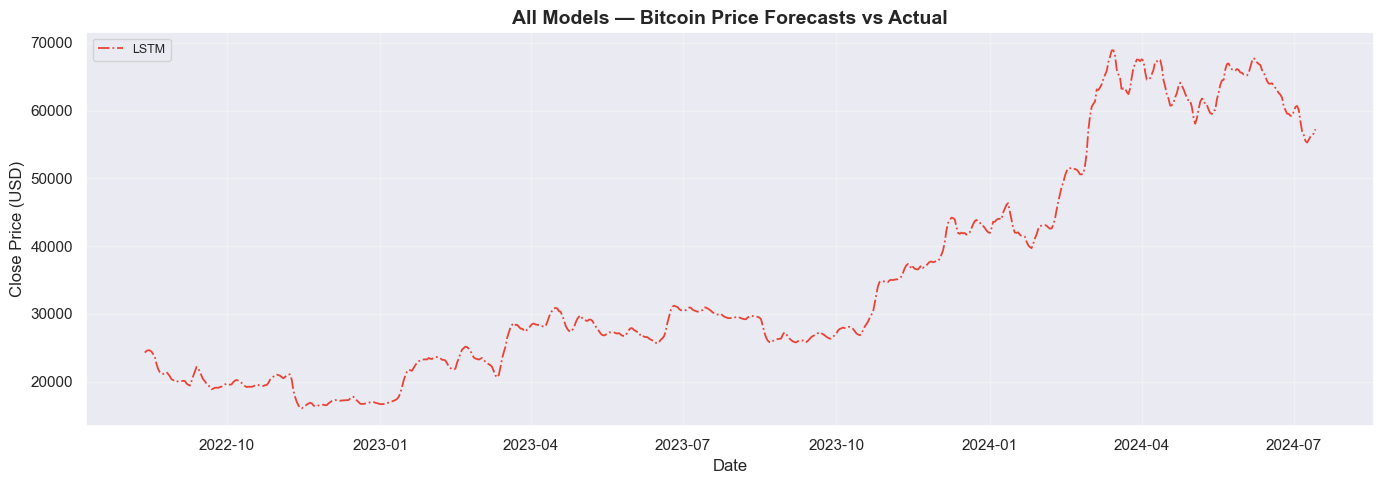

In [16]:
for name, idx, pred, color, ls in model_preds:
    n = min(len(idx), len(pred))
    plt.plot(idx[:n], pred[:n], label=name, color=color, linewidth=1.3, linestyle=ls)
    plt.title('All Models — Bitcoin Price Forecasts vs Actual', fontsize=14, fontweight='bold')
    plt.xlabel('Date'); plt.ylabel('Close Price (USD)')
    plt.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig('nb3_07_all_models_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()

## Section 6 : Model Comparison Charts

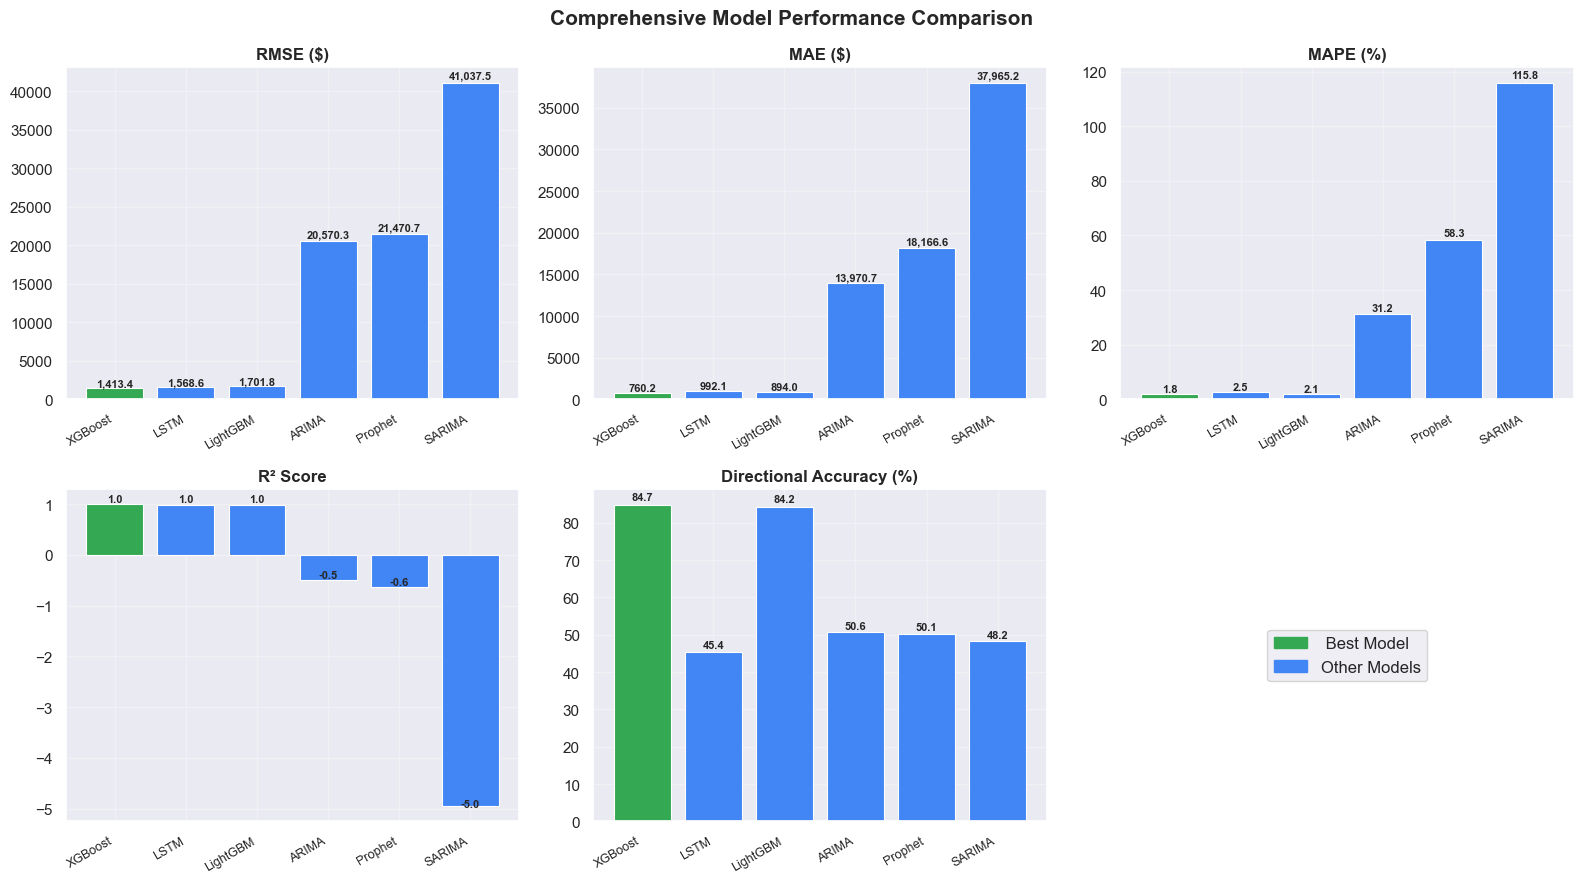

In [17]:
palette = ['#34A853' if i == 0 else '#4285F4' for i in range(len(results_df))]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
metrics = ['RMSE', 'MAE', 'MAPE', 'R2', 'Dir_Acc']
titles  = ['RMSE ($)', 'MAE ($)', 'MAPE (%)', 'R² Score', 'Directional Accuracy (%)']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    bars = ax.bar(results_df.index, results_df[metric], color=palette, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.01,
        f'{val:,.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
# Remove unused subplot
axes[1, 2].axis('off')
    
# Add legend
green_patch = mpatches.Patch(color='#34A853', label=' Best Model')
blue_patch  = mpatches.Patch(color='#4285F4', label='Other Models')
axes[1, 2].legend(handles=[green_patch, blue_patch], loc='center', fontsize=12)
    
plt.suptitle('Comprehensive Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('nb3_08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

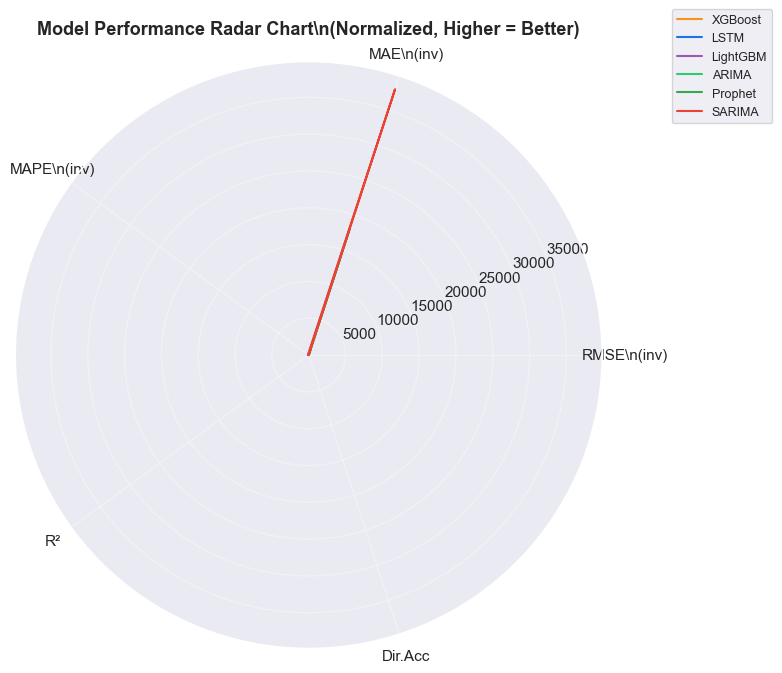

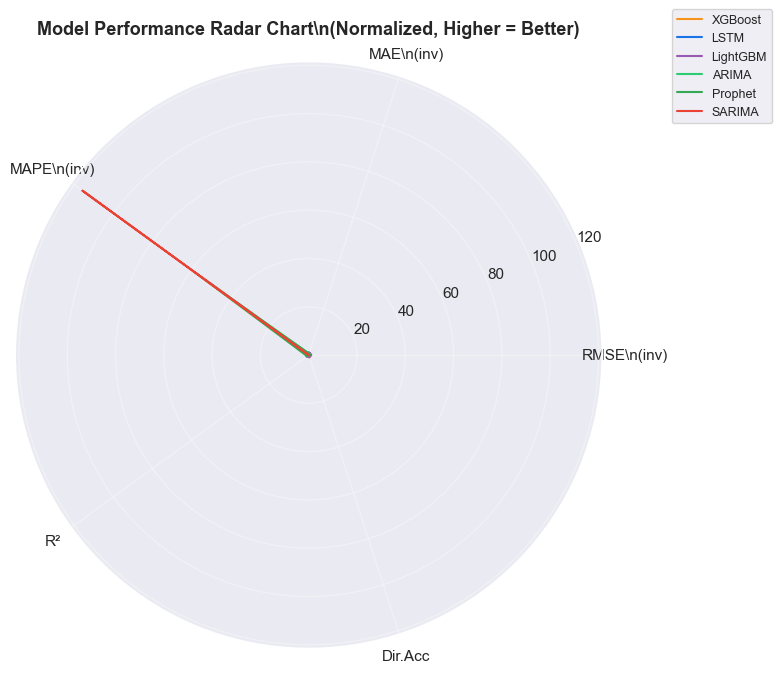

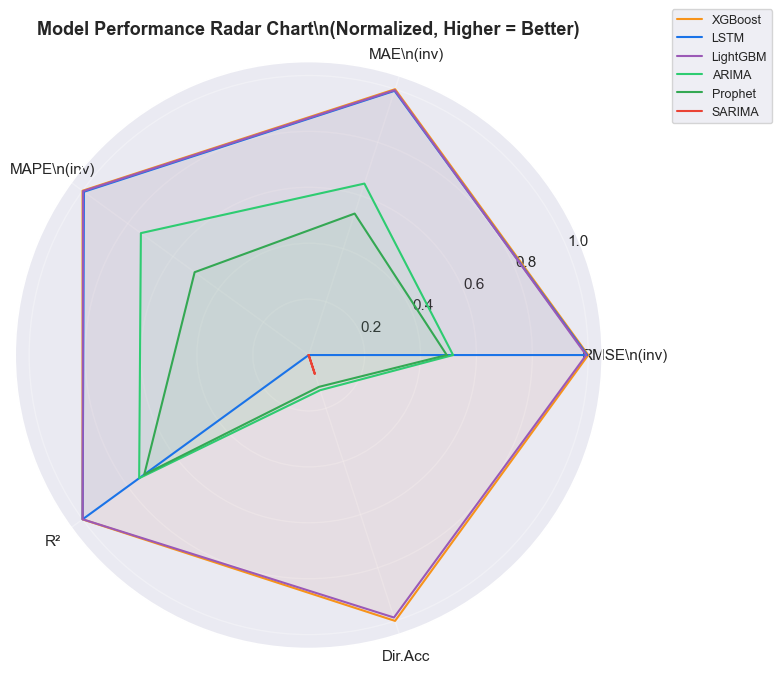

In [18]:
# ── Radar Chart ──
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
    
# Normalize metrics (lower RMSE/MAE/MAPE is better → invert)
radar_df = results_df[['RMSE','MAE','MAPE','R2','Dir_Acc']].copy()
for col in ['RMSE','MAE','MAPE']:
    radar_df[col] = 1 - (radar_df[col] - radar_df[col].min()) / (radar_df[col].max() - radar_df[col].min() + 1e-10)
    for col in ['R2','Dir_Acc']:
        radar_df[col] = (radar_df[col] - radar_df[col].min()) / (radar_df[col].max() - radar_df[col].min() + 1e-10)

    labels   = ['RMSE\\n(inv)', 'MAE\\n(inv)', 'MAPE\\n(inv)', 'R²', 'Dir.Acc']
    N        = len(labels)
    angles   = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles  += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors  = ['#F7931A','#1A73E8','#9B59B6','#2ECC71','#34A853','#EA4335']
    
    for (model, row), color in zip(radar_df.iterrows(), colors):
        values = row.tolist() + [row.tolist()[0]]
        ax.plot(angles, values, color=color, linewidth=1.5, label=model)
        ax.fill(angles, values, color=color, alpha=0.05)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=11)
    ax.set_title('Model Performance Radar Chart\\n(Normalized, Higher = Better)', fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
    plt.tight_layout()
    plt.savefig('nb3_09_radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

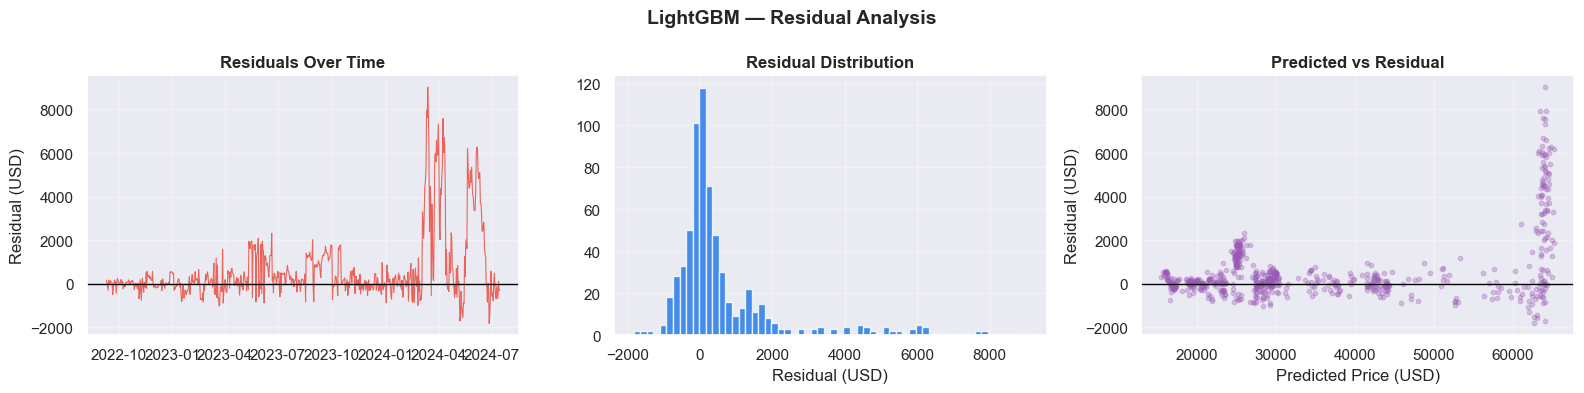

In [22]:
# ── Residual Analysis for Best ML Model (LightGBM) ──
n = min(len(actual_ml), len(lgb_pred))
residuals = actual_ml.values[:n] - lgb_pred.values[:n]

fig, axesi = plt.subplots(1, 3, figsize=(16, 4))
    
axesi[0].plot(actual_ml.index[:n], residuals, color='#EA4335', linewidth=0.8, alpha=0.8)
axesi[0].axhline(0, color='black', linewidth=1)
axesi[0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
axesi[0].set_ylabel('Residual (USD)')
    
axesi[1].hist(residuals, bins=60, color='#1A73E8', edgecolor='white', alpha=0.8)
axesi[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axesi[1].set_xlabel('Residual (USD)')
    
axesi[2].scatter(lgb_pred.values[:n], residuals, alpha=0.3, color='#9B59B6', s=10)
axesi[2].axhline(0, color='black', linewidth=1)
axesi[2].set_title('Predicted vs Residual', fontsize=12, fontweight='bold')
axesi[2].set_xlabel('Predicted Price (USD)')
axesi[2].set_ylabel('Residual (USD)')

plt.suptitle('LightGBM — Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb3_10_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## Section : 7 Feature Importance (XGBoost & LightGBM)

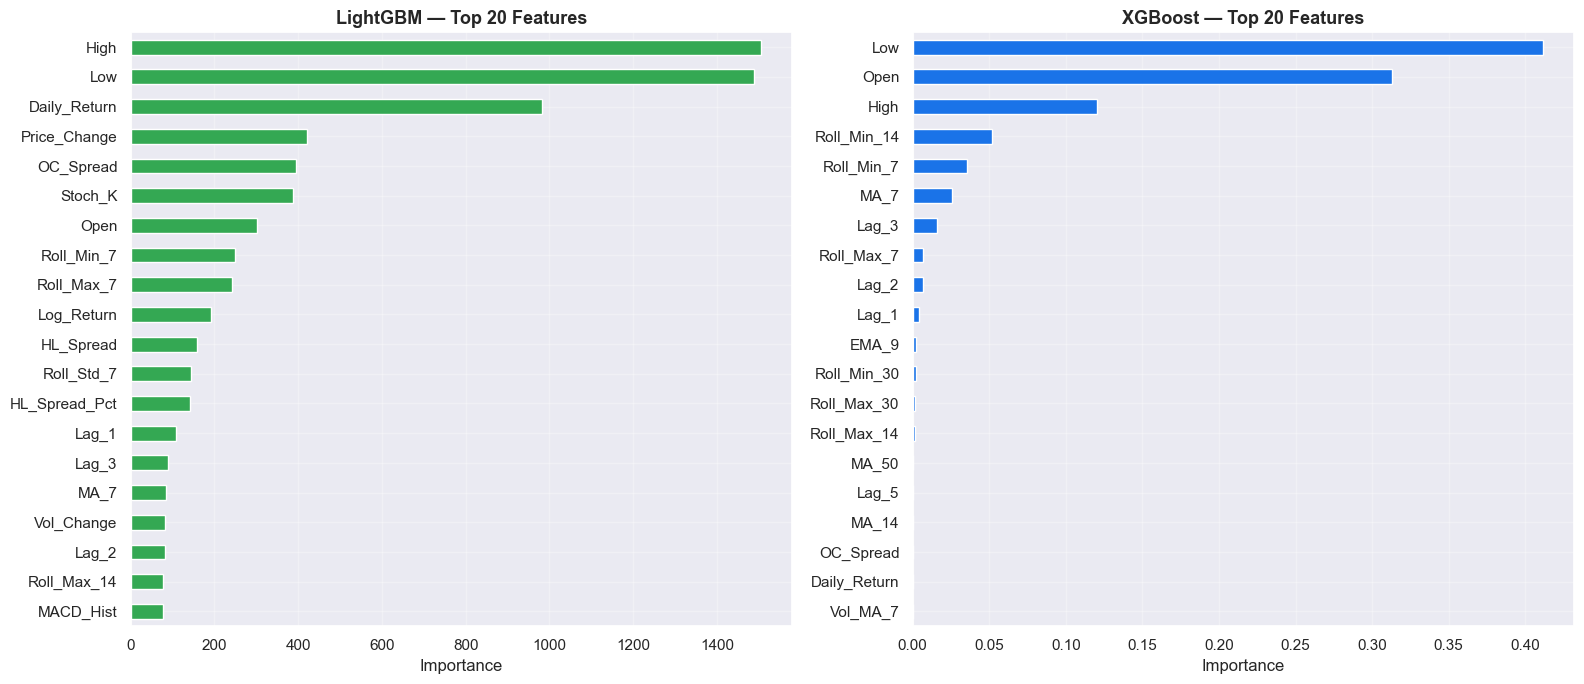

In [24]:
import xgboost as xgb

feature_cols = joblib.load('models/feature_cols.pkl')
lgb_model    = joblib.load('models/lgb_model.pkl')
xgb_model    = xgb.XGBRegressor()
xgb_model.load_model('models/xgb_model.json')

lgb_imp = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(20)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

lgb_imp.plot(kind='barh', ax=axes[0], color='#34A853', edgecolor='white')
axes[0].set_title('LightGBM — Top 20 Features', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance')

xgb_imp.plot(kind='barh', ax=axes[1], color='#1A73E8', edgecolor='white')
axes[1].set_title('XGBoost — Top 20 Features', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('nb3_11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 : 30-Day Future Forecast